In [1]:
!pip install kaggle -q

!mkdir -p ~/.kaggle

In [2]:
!pip install kaggle -q

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# تحميل الداتا
!kaggle datasets download -d juhibhojani/house-price
!unzip -o house-price.zip

Dataset URL: https://www.kaggle.com/datasets/juhibhojani/house-price
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 6.61M/6.61M [00:00<00:00, 109MB/s]

Archive:  house-price.zip
  inflating: house_prices.csv        


In [4]:
import pandas as pd

df = pd.read_csv("house_prices.csv")

# نشوف شكل الداتا
df.shape

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
# معلومات عن الأعمدة
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [6]:
# ملخص إحصائي
df.describe()

# نسبة القيم الفاضية في كل عمود
df.isna().mean().sort_values(ascending=False)

,0
Plot Area,1.000000
Dimensions,1.000000
Society,0.584853
Super Area,0.574225
Car Parking,0.551146
overlooking,0.434254
Carpet Area,0.430185
facing,0.374514
Ownership,0.349366
Balcony,0.260944


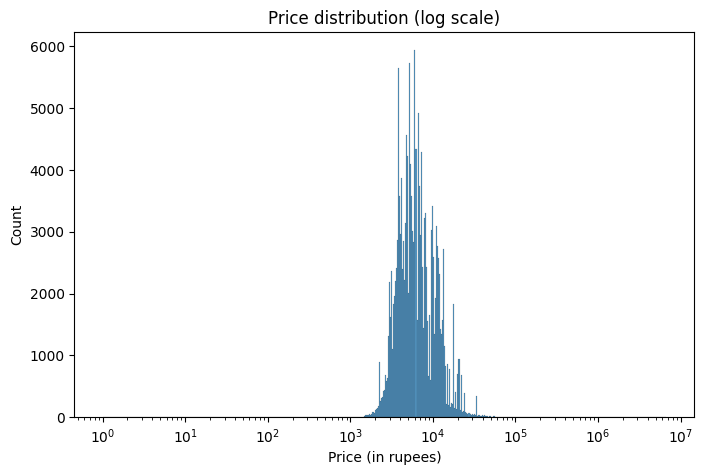

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# لازم الأول نحول السعر لرقم (هنعمل الفانكشن الكاملة بعد شوية)
# مؤقتًا هنجرب نشوف عمود Price (in rupees) اللي هو already رقمي جزئيًا
plt.figure(figsize=(8,5))
sns.histplot(df["Price (in rupees)"].dropna(), log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

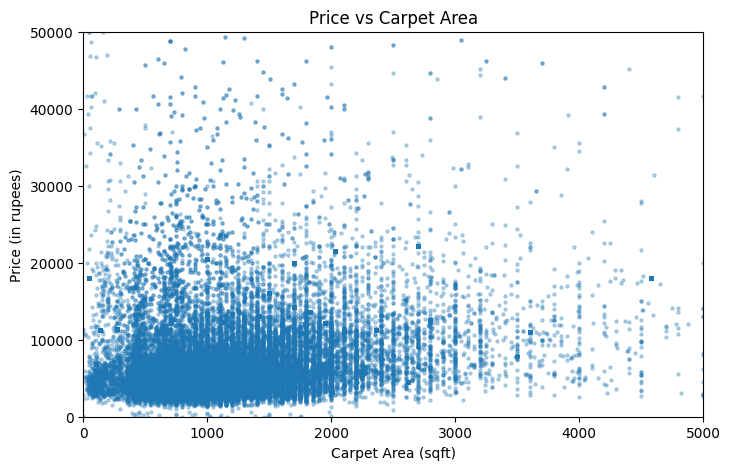

In [8]:
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r'[\d,]+\.?\d*', x)
    if not match:
        return None
    num = float(match.group().replace(",", ""))
    if "sqm" in x:
        num = num * 10.764
    return num

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

plt.figure(figsize=(8,5))
plt.scatter(df["carpet_area_sqft"], df["Price (in rupees)"], alpha=0.3, s=5)
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (in rupees)")
plt.title("Price vs Carpet Area")
plt.xlim(0, 5000)
plt.ylim(0, 50000)
plt.show()

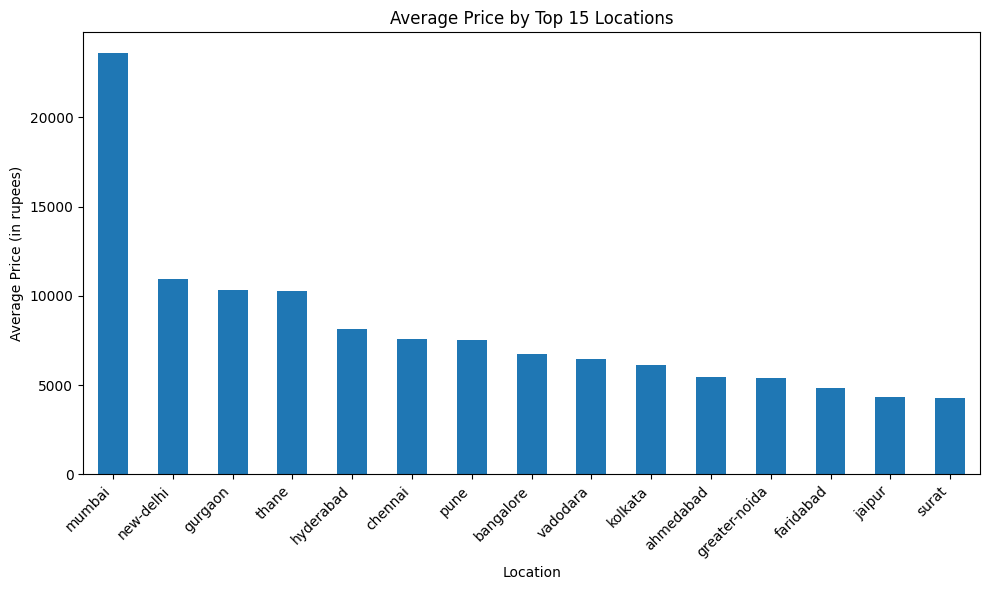

In [9]:
top_locations = df["location"].value_counts().head(15).index

avg_price_by_location = df[df["location"].isin(top_locations)].groupby("location")["Price (in rupees)"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_price_by_location.plot(kind="bar")
plt.title("Average Price by Top 15 Locations")
plt.ylabel("Average Price (in rupees)")
plt.xlabel("Location")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

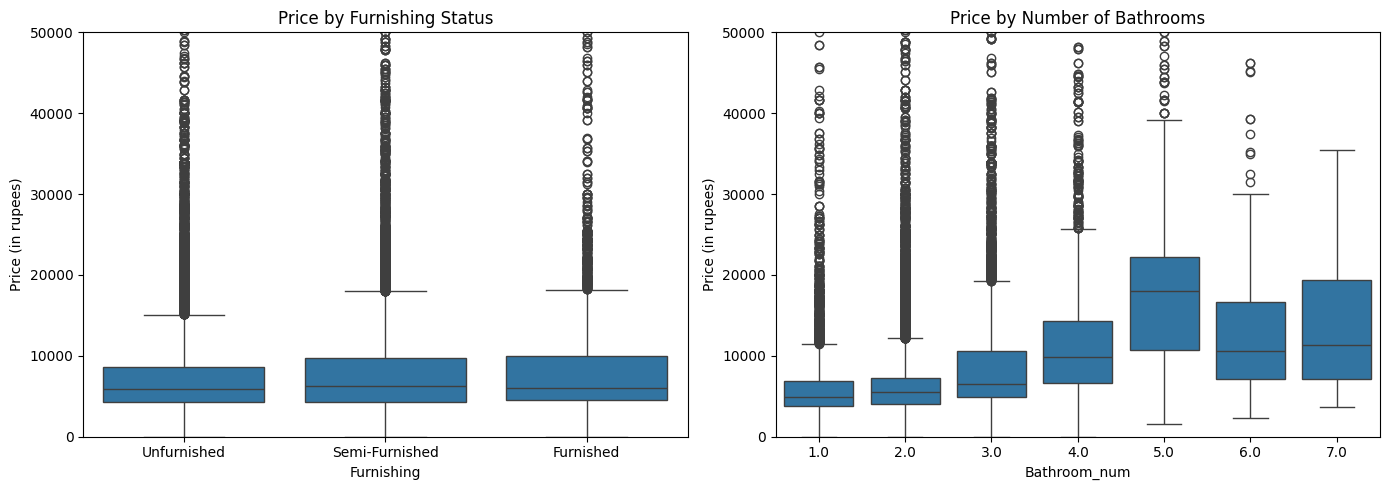

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Box plot 1: السعر حسب حالة الفرش
sns.boxplot(data=df, x="Furnishing", y="Price (in rupees)", ax=axes[0])
axes[0].set_title("Price by Furnishing Status")
axes[0].set_ylim(0, 50000)

df["Bathroom_num"] = pd.to_numeric(df["Bathroom"], errors="coerce")
sns.boxplot(data=df, x="Bathroom_num", y="Price (in rupees)", ax=axes[1])
axes[1].set_title("Price by Number of Bathrooms")
axes[1].set_ylim(0, 50000)
axes[1].set_xlim(-0.5, 6.5)

plt.tight_layout()
plt.show()

In [11]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

print(f"عدد الصفوف بعد حذف الأسعار الغير صالحة: {df.shape[0]}")
print(df["price_clean"].describe())

عدد الصفوف بعد حذف الأسعار الغير صالحة: 177847
count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64


In [12]:
# نتأكد كام قيمة فاضية في المساحة
print(f"عدد القيم الفاضية في carpet_area_sqft: {df['carpet_area_sqft'].isna().sum()}")
print(f"من إجمالي: {df.shape[0]}")

df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["carpet_area_sqft"].median())

print(df["carpet_area_sqft"].describe())

عدد القيم الفاضية في carpet_area_sqft: 76325
من إجمالي: 177847
count    177847.000000
mean       1156.038431
std        2368.876276
min           1.000000
25%        1000.000000
50%        1050.000000
75%        1170.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64


In [13]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first_part = x.split("out of")[0].strip()
    if "ground" in first_part:
        return 0
    if "basement" in first_part:
        return -1
    try:
        return float(first_part)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

print(df["floor_num"].describe())

count    177847.000000
mean          4.440457
std           4.617705
min          -1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max         200.000000
Name: floor_num, dtype: float64


In [14]:
# تحويل الثلاثة أعمدة لأرقام
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col + "_num"] = pd.to_numeric(df[col], errors="coerce")
    df[col + "_num"] = df[col + "_num"].fillna(df[col + "_num"].median())

print(df[["Bathroom_num", "Balcony_num", "Car Parking_num"]].describe())

        Bathroom_num    Balcony_num  Car Parking_num
count  177847.000000  177847.000000              0.0
mean        2.446103       2.008878              NaN
std         0.850811       0.815570              NaN
min         1.000000       1.000000              NaN
25%         2.000000       1.000000              NaN
50%         2.000000       2.000000              NaN
75%         3.000000       2.000000              NaN
max        10.000000      10.000000              NaN


In [15]:
import re

def parse_car_parking(x):
    if not isinstance(x, str):
        return None
    match = re.search(r'\d+', x)
    if match:
        return float(match.group())
    return None

for col in ["Bathroom", "Balcony"]:
    df[col + "_num"] = pd.to_numeric(df[col], errors="coerce")
    df[col + "_num"] = df[col + "_num"].fillna(df[col + "_num"].median())

# نصلح Car Parking بالطريقة الصح
df["Car Parking_num"] = df["Car Parking"].apply(parse_car_parking)
df["Car Parking_num"] = df["Car Parking_num"].fillna(0)  # لو مفيش بيانات، معناها الأغلب مفيش باركينج

print(df[["Bathroom_num", "Balcony_num", "Car Parking_num"]].describe())

        Bathroom_num    Balcony_num  Car Parking_num
count  177847.000000  177847.000000    177847.000000
mean        2.446103       2.008878         1.845946
std         0.850811       0.815570        21.550934
min         1.000000       1.000000         0.000000
25%         2.000000       1.000000         0.000000
50%         2.000000       2.000000         0.000000
75%         3.000000       2.000000         1.000000
max        10.000000      10.000000       999.000000


In [16]:
def group_top_n(series, n=50):
    top_values = series.value_counts().head(n).index
    return series.apply(lambda x: x if x in top_values else "other")

df["location_grouped"] = group_top_n(df["location"], n=50)

print(f"عدد القيم الفريدة في location قبل: {df['location'].nunique()}")
print(f"عدد القيم الفريدة في location_grouped بعد: {df['location_grouped'].nunique()}")
print(df["location_grouped"].value_counts().head(10))

عدد القيم الفريدة في location قبل: 81
عدد القيم الفريدة في location_grouped بعد: 51
location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64


In [17]:
# حذف الأعمدة الغير مفيده
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area"])

print(f"شكل الداتا بعد حذف الأعمدة الزيادة: {df.shape}")
print(df.columns.tolist())

شكل الداتا بعد حذف الأعمدة الزيادة: (177847, 23)
['Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'carpet_area_sqft', 'Bathroom_num', 'price_clean', 'floor_num', 'Balcony_num', 'Car Parking_num', 'location_grouped']


In [18]:
# نحسب price per sqft عشان نلاقي القيم الشاذة
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

# نحدد حدود الـ 1st و99th percentile
low = df["price_per_sqft"].quantile(0.01)
high = df["price_per_sqft"].quantile(0.99)

print(f"الحد الأدنى: {low:.2f}, الحد الأقصى: {high:.2f}")
print(f"عدد الصفوف قبل الحذف: {df.shape[0]}")

df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]

print(f"عدد الصفوف بعد حذف الـ outliers: {df.shape[0]}")

الحد الأدنى: 1571.43, الحد الأقصى: 77142.86
عدد الصفوف قبل الحذف: 177847
عدد الصفوف بعد حذف الـ outliers: 174585


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "Bathroom_num", "Balcony_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (139668, 9)
X_test shape: (34917, 9)


In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# الموديل الأول: Linear Regression
model_lr = Pipeline([("prep", preprocessor),
                      ("reg", LinearRegression())])
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

print("=== Linear Regression ===")
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", root_mean_squared_error(y_test, pred_lr))
print("R²  :", r2_score(y_test, pred_lr))

=== Linear Regression ===
MAE : 4413547.501523442
RMSE: 7143162.609129578
R²  : 0.6508554779851854


In [21]:
model_rf = Pipeline([("prep", preprocessor),
                      ("reg", RandomForestRegressor(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1))])
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

print("=== Random Forest ===")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", root_mean_squared_error(y_test, pred_rf))
print("R²  :", r2_score(y_test, pred_rf))

=== Random Forest ===
MAE : 1444530.0296778386
RMSE: 4206246.203437889
R²  : 0.878936412773978


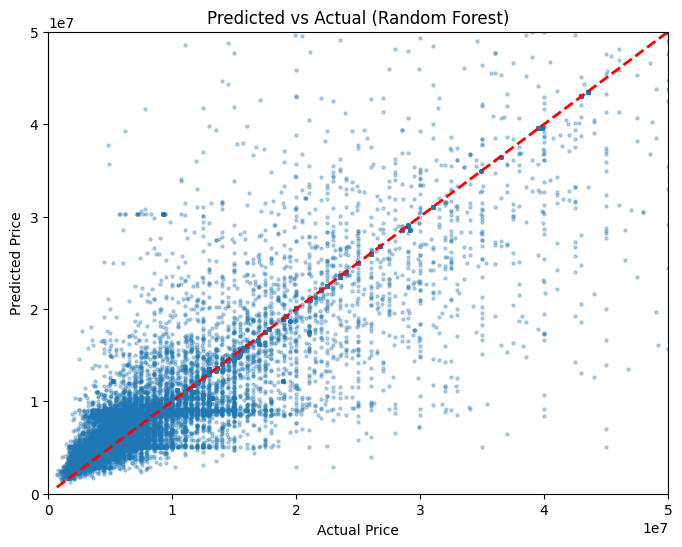

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_rf, alpha=0.3, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (Random Forest)")
plt.xlim(0, 50000000)
plt.ylim(0, 50000000)
plt.show()

In [23]:
import joblib
import json

# تصدير الموديل الفايز (Random Forest) بالكامل مع الـ Pipeline
joblib.dump(model_rf, "house_price.pkl")

# Sanity check: نتأكد إنه بيشتغل صح بعد التحميل
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

# نحفظ قائمة الـ locations المسموحة (لل dropdown في الفرونت إند)
locations_list = sorted(df["location_grouped"].unique().tolist())
json.dump(locations_list, open("locations.json", "w"))

print(f"عدد الـ locations المحفوظة: {len(locations_list)}")
print("تم حفظ house_price.pkl و locations.json بنجاح")

Reloaded prediction: [6937203.32609194]
عدد الـ locations المحفوظة: 51
تم حفظ house_price.pkl و locations.json بنجاح


In [24]:
import sklearn
print(sklearn.__version__)

1.6.1


In [25]:
import joblib
joblib.dump(model_rf, "house_price.pkl")
print("تم الحفظ")

تم الحفظ
